# Семинар 2. Линейная регрессия на практике

Будем предсказывать цену дома: обучим простую модель, проверим её на других домах и постепенно улучшим.

## Датасет: цены домов в Ames

В таблице **1460 продаж домов в Ames, штат Айова, за 2006–2010 годы**. Одна строка — один дом. Есть 79 исходных характеристик, идентификатор `Id` и ответ `SalePrice` — цена продажи в долларах того периода. `Id` не используем как признак.

Начнём с небольшого набора понятных характеристик, затем сравним его с моделью на всех признаках.

| Столбец | Что означает |
|---|---|
| `SalePrice` | Цена продажи, доллары — её предсказываем |
| `GrLivArea` | Надземная жилая площадь, квадратные футы |
| `OverallQual` | Оценка качества материалов и отделки, от 1 до 10 |
| `YearBuilt` | Год постройки |
| `GarageCars` | Вместимость гаража, число автомобилей |
| `LotFrontage` | Длина границы участка вдоль улицы, футы; есть пропуски |
| `Neighborhood` | Район города, категория |

Остальные характеристики описывают участок, подвал, крышу, отопление, ремонт, условия продажи и другие свойства. Среди них есть числа, категории и пропуски. **1 ft² ≈ 0,093 м².** Это историческая учебная задача, не оценка сегодняшней рыночной цены.

In [1]:
#@title Начать: подключить библиотеки и загрузить данные
import base64, gzip, hashlib, io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score

_csv = gzip.decompress(base64.b64decode('...'))
assert hashlib.sha256(_csv).hexdigest() == '1e18addf81e5e4d347cc17ee6075bbe4a42b7fa26b9e5b063e8f692a5f929d41'
houses = pd.read_csv(io.BytesIO(_csv))
del _csv
SEED = 42
BLUE, CYAN, ORANGE = '#102D69', '#119DD2', '#DE7634'
plt.rcParams.update({'figure.figsize': (8, 4), 'figure.dpi': 110,
                     'axes.spines.top': False, 'axes.spines.right': False,
                     'axes.grid': True, 'grid.alpha': .2})
pd.set_option('display.precision', 3)
print('Готово: 1460 домов, библиотеки подключены. Данные уже внутри ноутбука.')

Готово: 1460 домов, библиотеки подключены. Данные уже внутри ноутбука.


## 1. Обучаем первую модель

Начнём с одного признака — `GrLivArea`: **чем больше дом, тем он дороже?**

Сразу отложим часть домов:

- **train, 60%** — на них модель подбирает коэффициенты;
- **valid, 20%** — по ошибке на них сравниваем наши улучшения;
- **test, 20%** — финальная проверка в самом конце.

Во всех сравнениях используем одни и те же дома. Сейчас смотрим только на train.

Train: 876 домов | valid: 292 | test: 292


,GrLivArea,SalePrice
Id,,
684,1668,285000
1078,1096,138800
464,1660,188700
658,1502,149000
836,1067,128000


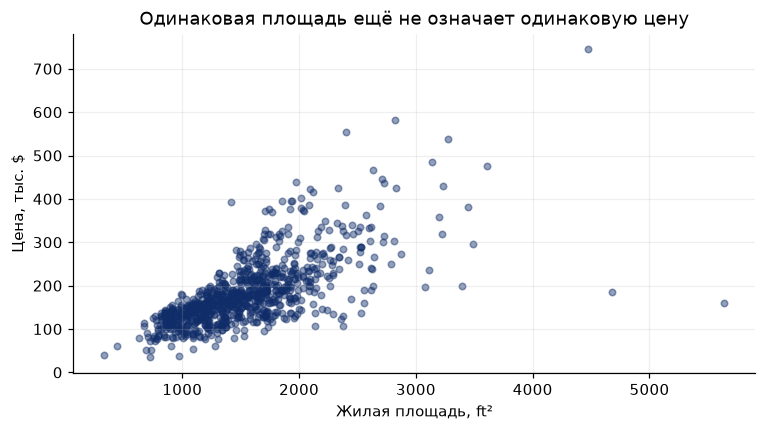

In [2]:
X = houses.set_index('Id').drop(columns='SalePrice').copy()
X['MSSubClass'] = X['MSSubClass'].astype(str)  # Это код типа дома, а не количество.
y = houses.set_index('Id')['SalePrice']

X_develop, X_test, y_develop, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED)
X_train, X_valid, y_train, y_valid = train_test_split(
    X_develop, y_develop, test_size=0.25, random_state=SEED)
print(f'Train: {len(X_train)} домов | valid: {len(X_valid)} | test: {len(X_test)}')

display(X_train[['GrLivArea']].join(y_train).head())
plt.scatter(X_train['GrLivArea'], y_train / 1000, s=18, alpha=.45, color=BLUE)
plt.xlabel('Жилая площадь, ft²'); plt.ylabel('Цена, тыс. $')
plt.title('Одинаковая площадь ещё не означает одинаковую цену')
plt.show()

`fit(признаки, ответы)` обучает модель. `predict(признаки)` выдаёт прогнозы. Ответы для новых домов в `predict` не передаются.

**Перед запуском:** сможет ли одна прямая точно описать все точки на графике?

In [3]:
area_columns = ['GrLivArea']
area_model = LinearRegression()
area_model.fit(X_train[area_columns], y_train)

area_train_pred = area_model.predict(X_train[area_columns])
area_valid_pred = area_model.predict(X_valid[area_columns])
display(pd.DataFrame({'Реальная цена, $': y_valid,
                      'Прогноз по площади, $': area_valid_pred}).head())

,"Реальная цена, $","Прогноз по площади, $"
Id,,
1412,140000,194759.289
316,188500,171264.227
584,325000,304967.060
1343,228500,244636.519
892,172500,196252.620


## 2. Проверяем, полезна ли модель

Отдельные прогнозы трудно сравнивать — нужна одна мера ошибки. Возьмём **RMSE**: она измеряется в долларах и сильнее реагирует на большие промахи. Меньше — лучше. Рядом будем смотреть **MAE**, среднюю абсолютную ошибку в долларах.

Для ориентира предскажем каждому дому одну и ту же **среднюю цену из train**. Модель по площади должна хотя бы обойти этот простой прогноз.

Добавим **R²** — сравнение квадратичной ошибки модели с ошибкой прогноза средним:

$$R^2 = 1 - \frac{\sum_i (y_i-\hat y_i)^2}{\sum_i (y_i-\bar y)^2}.$$

Здесь $\bar y$ — средняя цена на той выборке, где считаем метрику. **R² = 1** означает точный прогноз; **R² = 0** — такую же ошибку, как у этого среднего; **R² < 0** — хуже. Это не процент угаданных цен. Наш ориентир берёт среднее из train, поэтому на valid его R² может быть немного ниже нуля.

Следующая служебная ячейка заводит таблицу: в неё будем добавлять каждое улучшение. Столбец **«Шаг»** связывает строку с разделом семинара; **0** — константный ориентир. Сравниваем варианты по RMSE valid, а R² и MAE помогают читать результат.

In [4]:
#@title Таблица сравнения: выполнить один раз
scores = {}
def add_result(step, name, train_pred, valid_pred):
    scores[name] = {
        'Шаг': str(step),
        'RMSE train, $': root_mean_squared_error(y_train, train_pred),
        'RMSE valid, $': root_mean_squared_error(y_valid, valid_pred),
        'MAE valid, $': mean_absolute_error(y_valid, valid_pred),
        'R² valid': r2_score(y_valid, valid_pred)
    }
    table = pd.DataFrame.from_dict(scores, orient='index')
    display(table.round({'RMSE train, $': 0, 'RMSE valid, $': 0,
                         'MAE valid, $': 0, 'R² valid': 3}))

In [5]:
mean_price = y_train.mean()
scores['Средняя цена'] = {
    'Шаг': '0',
    'RMSE train, $': root_mean_squared_error(y_train, np.full(len(y_train), mean_price)),
    'RMSE valid, $': root_mean_squared_error(y_valid, np.full(len(y_valid), mean_price)),
    'MAE valid, $': mean_absolute_error(y_valid, np.full(len(y_valid), mean_price)),
    'R² valid': r2_score(y_valid, np.full(len(y_valid), mean_price))
}
add_result('1', 'Только площадь', area_train_pred, area_valid_pred)

,Шаг,"RMSE train, $","RMSE valid, $","MAE valid, $",R² valid
Средняя цена,0,77178.0,77389.0,57794.0,-0.000
Только площадь,1,56288.0,53091.0,36137.0,0.529


**Обсудим:** насколько площадь помогла по сравнению со средней ценой? Почему недостаточно смотреть только на `RMSE train`?

На train модель уже подбирала коэффициенты. Нас интересуют и другие дома, поэтому улучшения выбираем по **RMSE valid**. Большой разрыв между train и valid — повод проверить, не подстроились ли мы слишком сильно под обучающие данные.

## 3. Добавляем ещё три признака

Кроме площади возьмём `OverallQual` — оценку качества дома, `YearBuilt` — год постройки и `GarageCars` — число мест в гараже. В этих четырёх столбцах нет пропусков.

Код обучения почти не меняется: теперь у модели четыре входных столбца вместо одного. **До запуска предположите, что произойдёт с ошибкой.**

In [6]:
numeric_columns = ['GrLivArea', 'OverallQual', 'YearBuilt', 'GarageCars']
numeric_model = LinearRegression()
numeric_model.fit(X_train[numeric_columns], y_train)

add_result('3', 'Четыре признака',
           numeric_model.predict(X_train[numeric_columns]),
           numeric_model.predict(X_valid[numeric_columns]))

,Шаг,"RMSE train, $","RMSE valid, $","MAE valid, $",R² valid
Средняя цена,0,77178.0,77389.0,57794.0,-0.000
Только площадь,1,56288.0,53091.0,36137.0,0.529
Четыре признака,3,39608.0,37432.0,26358.0,0.766


Посмотрите, как изменились обе ошибки. Больше признаков даёт модели больше возможностей, но **пользу проверяем на valid**. Добавлять столбцы просто ради их количества не нужно.

## 4. Добавляем неполные данные и район

### 4.1. Ещё один числовой признак

`LotFrontage` — длина границы участка вдоль улицы, в футах. В нём есть пропуски, а `LinearRegression` не умеет работать с ними напрямую.

Заменим пропуски медианой **из train**. `SimpleImputer` запомнит её при обучении и применит к valid. `Pipeline` связывает два шага: **заполнить пропуски → сделать прогноз**. У него остаются те же `fit` и `predict`.

In [7]:
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

numeric_more = numeric_columns + ['LotFrontage']
print('Пропусков LotFrontage на train:', X_train['LotFrontage'].isna().sum())

imputed_model = Pipeline([
    ('fill_missing', SimpleImputer(strategy='median')),
    ('regression', LinearRegression())
])
imputed_model.fit(X_train[numeric_more], y_train)
add_result('4.1', 'Пять признаков + пропуски',
           imputed_model.predict(X_train[numeric_more]),
           imputed_model.predict(X_valid[numeric_more]))

Пропусков LotFrontage на train: 163


,Шаг,"RMSE train, $","RMSE valid, $","MAE valid, $",R² valid
Средняя цена,0,77178.0,77389.0,57794.0,-0.000
Только площадь,1,56288.0,53091.0,36137.0,0.529
Четыре признака,3,39608.0,37432.0,26358.0,0.766
Пять признаков + пропуски,4.1,39534.0,37307.0,26036.0,0.768


### 4.2. Район дома

`Neighborhood` содержит названия районов. Нельзя просто заменить их числами 1, 2, 3: модель воспримет их как величины.

**One-hot encoding** — отдельный столбец 0/1 для каждого района. Например:

| Район | NAmes | CollgCr | OldTown |
|---|---:|---:|---:|
| NAmes | 1 | 0 | 0 |
| CollgCr | 0 | 1 | 0 |
| OldTown | 0 | 0 | 1 |

`ColumnTransformer` распределит работу: числа отправит на заполнение пропусков, район — в `OneHotEncoder`. Результат передастся той же линейной регрессии. Вся обработка обучается на train вместе с моделью.

In [8]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

all_columns = numeric_more + ['Neighborhood']
prepare = ColumnTransformer([
    ('numbers', SimpleImputer(strategy='median'), numeric_more),
    ('district', OneHotEncoder(handle_unknown='ignore', sparse_output=False), ['Neighborhood'])
])
district_model = Pipeline([
    ('prepare', prepare),
    ('regression', LinearRegression())
])
district_model.fit(X_train[all_columns], y_train)

district_valid_pred = district_model.predict(X_valid[all_columns])
add_result('4.2', 'Добавили район',
           district_model.predict(X_train[all_columns]),
           district_valid_pred)

,Шаг,"RMSE train, $","RMSE valid, $","MAE valid, $",R² valid
Средняя цена,0,77178.0,77389.0,57794.0,-0.000
Только площадь,1,56288.0,53091.0,36137.0,0.529
Четыре признака,3,39608.0,37432.0,26358.0,0.766
Пять признаков + пропуски,4.1,39534.0,37307.0,26036.0,0.768
Добавили район,4.2,35673.0,33900.0,22737.0,0.808


`handle_unknown='ignore'` позволит сделать прогноз, даже если при проверке встретится незнакомый район: его индикаторы будут нулевыми.

**Обсудим:** что помогло сильнее — длина границы участка или район? Почему нельзя сначала посчитать медианы по всем данным и только потом разделить их?

Посмотрим на пять самых больших ошибок **на valid**. Это подсказка, что можно улучшать дальше, а не список строк для автоматического удаления.

In [9]:
errors = X_valid[['GrLivArea', 'OverallQual', 'Neighborhood']].copy()
errors['Цена, $'] = y_valid
errors['Прогноз, $'] = district_valid_pred
errors['Ошибка, $'] = np.abs(y_valid - district_valid_pred)
display(errors.nlargest(5, 'Ошибка, $').round(0))

,GrLivArea,OverallQual,Neighborhood,"Цена, $","Прогноз, $","Ошибка, $"
Id,,,,,,
1170,3627,10,NoRidge,625000,415015.0,209985.0
179,2234,9,StoneBr,501837,347112.0,154725.0
1182,1652,8,Crawfor,392500,255033.0,137467.0
1325,1795,8,Somerst,147000,262550.0,115550.0
54,1842,9,Veenker,385000,274934.0,110066.0


### 4.3. Бейзлайн: обычный LinearRegression на всех признаках

Проверим естественную идею: **что, если сразу отдать модели все 79 характеристик?** Оставим обычный `LinearRegression`, без подбора параметров, новых признаков и логарифмирования.

Технически всё равно нужно заполнить пропуски и перевести категории в числа. Используем уже знакомую обработку: медианы для чисел, отдельную категорию для пропусков и one-hot для категорий. Все значения обработки узнаём только из train. `Id` и `SalePrice` в признаки не попадают.

In [10]:
raw_columns = X_train.columns.tolist()
raw_numeric = X_train.select_dtypes(include='number').columns.tolist()
raw_categories = [c for c in raw_columns if c not in raw_numeric]

raw_prepare = ColumnTransformer([
    ('numbers', SimpleImputer(strategy='median'), raw_numeric),
    ('categories', Pipeline([
        ('fill_missing', SimpleImputer(strategy='constant', fill_value='__MISSING__')),
        ('encode', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ]), raw_categories)
])
raw_model = Pipeline([
    ('prepare', raw_prepare),
    ('regression', LinearRegression())
])
raw_model.fit(X_train[raw_columns], y_train)
print('Исходных признаков:', len(raw_columns))
add_result('4.3', 'Линрег: все признаки',
           raw_model.predict(X_train[raw_columns]),
           raw_model.predict(X_valid[raw_columns]))

Исходных признаков: 79


,Шаг,"RMSE train, $","RMSE valid, $","MAE valid, $",R² valid
Средняя цена,0,77178.0,77389.0,57794.0,-0.000
Только площадь,1,56288.0,53091.0,36137.0,0.529
Четыре признака,3,39608.0,37432.0,26358.0,0.766
Пять признаков + пропуски,4.1,39534.0,37307.0,26036.0,0.768
Добавили район,4.2,35673.0,33900.0,22737.0,0.808
Линрег: все признаки,4.3,17637.0,30071.0,19993.0,0.849


**Обсудим:** что произошло с ошибкой на train и на valid? Стал ли вариант «взять всё» лучше модели на шести понятных признаках? Оцениваем обе ошибки, а не только качество на обучении.

## 5. Пробуем обучаться на логарифме цены

При обучении в долларах большие промахи на дорогих домах сильно влияют на модель. Попробуем предсказывать **`log1p(цена)`**, чтобы уменьшить их влияние.

Возвращаемся к модели **из шага 4.2 — пять чисел и район**. Её признаки и обработку оставляем прежними. Меняем только ответ при `fit`, а прогноз возвращаем в доллары через `expm1` — обратную операцию. **Ошибки по-прежнему считаем в долларах**, чтобы сравнение оставалось честным.

Это гипотеза, а не обязательное улучшение. Проверим её на том же valid. `clone` создаст новую необученную копию нашей модели.

In [11]:
from sklearn.base import clone

log_model = clone(district_model)
log_model.fit(X_train[all_columns], np.log1p(y_train))

log_train_pred = np.expm1(log_model.predict(X_train[all_columns]))
log_valid_pred = np.expm1(log_model.predict(X_valid[all_columns]))
add_result('5', 'Логарифм цены', log_train_pred, log_valid_pred)

,Шаг,"RMSE train, $","RMSE valid, $","MAE valid, $",R² valid
Средняя цена,0,77178.0,77389.0,57794.0,-0.000
Только площадь,1,56288.0,53091.0,36137.0,0.529
Четыре признака,3,39608.0,37432.0,26358.0,0.766
Пять признаков + пропуски,4.1,39534.0,37307.0,26036.0,0.768
Добавили район,4.2,35673.0,33900.0,22737.0,0.808
Линрег: все признаки,4.3,17637.0,30071.0,19993.0,0.849
Логарифм цены,5,34794.0,30649.0,21166.0,0.843


**Обсудим:** какая модель теперь лучшая по RMSE valid? А по MAE valid? Эти метрики могут выбрать разные варианты. Для нашего выбора заранее договорились использовать RMSE.

После просмотра ошибок на valid можно пробовать улучшения. Но чем чаще мы это делаем, тем сильнее подстраиваемся под эту проверку. Перед финальным test осталось выбрать ещё одну настройку модели.

## 6. Подбираем параметр по сетке: GridSearchCV

В модели на всех признаках коэффициентов стало больше. Попробуем **Ridge** — линейную регрессию, которая сдерживает слишком большие веса. За силу этого ограничения отвечает `alpha`: больше значение — сильнее ограничение. Это настройка, которую выбираем до итогового обучения; сами коэффициенты по-прежнему находит `fit`.

Возьмём все признаки из шага 4.3. Числа приведём к сопоставимому масштабу через `StandardScaler`: иначе одинаковый штраф по-разному зависел бы от единиц измерения. Категории обрабатываем как раньше, цены оставляем в долларах.

**Сетка** — пять значений `alpha`: 0.1, 1, 10, 100, 1000. `GridSearchCV` проверит каждое на трёх разбиениях **внутри train**. Весь Pipeline передаём внутрь поиска: заполнение пропусков, масштабирование и кодирование каждый раз учатся только на обучающей части.

In [12]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, KFold

ridge_prepare = clone(raw_prepare)
ridge_prepare.set_params(numbers=Pipeline([
    ('fill_missing', SimpleImputer(strategy='median')),
    ('scale', StandardScaler())
]))
ridge_model = Pipeline([
    ('prepare', ridge_prepare),
    ('regression', Ridge())
])

search = GridSearchCV(
    ridge_model,
    param_grid={'regression__alpha': [0.1, 1, 10, 100, 1000]},
    scoring='neg_root_mean_squared_error',
    cv=KFold(n_splits=3, shuffle=True, random_state=SEED),
    n_jobs=1, error_score='raise'
)
search.fit(X_train[raw_columns], y_train)

grid_results = pd.DataFrame({
    'alpha': search.cv_results_['param_regression__alpha'],
    'Средняя RMSE внутри train, $': -search.cv_results_['mean_test_score']
})
display(grid_results.round({'Средняя RMSE внутри train, $': 0}))
print('Выбранная настройка:', search.best_params_)

tuned_model = search.best_estimator_
add_result('6', 'Ridge: подбор alpha',
           tuned_model.predict(X_train[raw_columns]),
           tuned_model.predict(X_valid[raw_columns]))

,alpha,"Средняя RMSE внутри train, $"
0,0.1,40276.0
1,1.0,36044.0
2,10.0,33709.0
3,100.0,34004.0
4,1000.0,38786.0


Выбранная настройка: {'regression__alpha': 10}


,Шаг,"RMSE train, $","RMSE valid, $","MAE valid, $",R² valid
Средняя цена,0,77178.0,77389.0,57794.0,-0.000
Только площадь,1,56288.0,53091.0,36137.0,0.529
Четыре признака,3,39608.0,37432.0,26358.0,0.766
Пять признаков + пропуски,4.1,39534.0,37307.0,26036.0,0.768
Добавили район,4.2,35673.0,33900.0,22737.0,0.808
Линрег: все признаки,4.3,17637.0,30071.0,19993.0,0.849
Логарифм цены,5,34794.0,30649.0,21166.0,0.843
Ridge: подбор alpha,6,23859.0,28711.0,18626.0,0.862


`regression__alpha` означает «параметр alpha у шага regression». Минус в `neg_root_mean_squared_error` нужен из-за соглашения sklearn: большее значение scorer считается лучшим. В таблице вернули обычную положительную RMSE.

`best_estimator_` — выбранный Pipeline, уже заново обученный на всём train. Теперь его результат на **том же valid** сравним с предыдущими строками. Самый удачный параметр не гарантирует победу над другим вариантом модели.

**Обсудим:** какой `alpha` выбрала сетка? Стал ли Ridge лучше обычного линрега на всех признаках? Как он выглядит на фоне модели с логарифмом цены?

## 7. Фиксируем модель и проверяем на test

Выбираем модель по RMSE valid, затем обучаем её заново на **train + valid**: теперь эти дома можно использовать вместе. Название модели и все настройки уже зафиксированы. Test не участвовал ни в обучении, ни в выборе.

В следующей ячейке `variants` просто хранит наши готовые варианты: модель, её столбцы и признак того, нужно ли преобразовывать цену.

In [13]:
from sklearn.dummy import DummyRegressor

variants = {
    'Средняя цена': (DummyRegressor(strategy='mean'), area_columns, False),
    'Только площадь': (area_model, area_columns, False),
    'Четыре признака': (numeric_model, numeric_columns, False),
    'Пять признаков + пропуски': (imputed_model, numeric_more, False),
    'Добавили район': (district_model, all_columns, False),
    'Линрег: все признаки': (raw_model, raw_columns, False),
    'Логарифм цены': (log_model, all_columns, True),
    'Ridge: подбор alpha': (tuned_model, raw_columns, False)
}
comparison = pd.DataFrame.from_dict(scores, orient='index')
best_name = comparison['RMSE valid, $'].idxmin()
estimator, columns, use_log = variants[best_name]
print('Выбрали по valid:', best_name)

final_model = clone(estimator)
final_target = np.log1p(y_develop) if use_log else y_develop
final_model.fit(X_develop[columns], final_target)
test_pred = final_model.predict(X_test[columns])
if use_log:
    test_pred = np.expm1(test_pred)

mean_test_pred = np.full(len(y_test), y_develop.mean())
display(pd.DataFrame({
    'Шаг': [scores[best_name]['Шаг'], '0'],
    'RMSE test, $': [root_mean_squared_error(y_test, test_pred),
                     root_mean_squared_error(y_test, mean_test_pred)],
    'MAE test, $': [mean_absolute_error(y_test, test_pred),
                    mean_absolute_error(y_test, mean_test_pred)],
    'R² test': [r2_score(y_test, test_pred), r2_score(y_test, mean_test_pred)]
}, index=[best_name, 'Средняя цена — ориентир']).round(
    {'RMSE test, $': 0, 'MAE test, $': 0, 'R² test': 3}))

Выбрали по valid: Ridge: подбор alpha


,Шаг,"RMSE test, $","MAE test, $",R² test
Ridge: подбор alpha,6,30613.0,19228.0,0.878
Средняя цена — ориентир,0,87619.0,62576.0,-0.001


**Последний вопрос:** на сколько модель обошла прогноз средней ценой? Какую абсолютную ошибку в среднем нужно ожидать по MAE?

Теперь результат test фиксируем. Если начать выбирать улучшения по этой таблице, test тоже превратится в данные для подбора.

<details><summary>Источники данных и материала</summary>

[Семинар ВШЭ, Е. Соколов и авторы курса](https://github.com/esokolov/ml-course-hse/blob/master/ml1-2026-spring/seminars/sem02-sklearn-linreg.ipynb): задача House Prices, sklearn, обработка признаков и преобразование цены. [Материалы семинаров ЦУ](https://docs.google.com/spreadsheets/d/10ttblKqi-Lo5X9dJ3fVNLoOuN2LL-WpwJupgkyI8aAw/edit): разбор ошибок и разделение обучения и проверки.

Данные — [House Prices / Ames Housing](https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques/data), исторические цены в долларах и площади в квадратных футах. CSV из исходного семинара ВШЭ встроен в этот файл. Проверяем прогноз для домов из той же совокупности; перенос на будущий рынок или другой город здесь не проверяется.

Документация: [R²](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.r2_score.html), [Ridge](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Ridge.html), [GridSearchCV](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html).

</details>